© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

English translation managed by Tamás Takács. The translation was produced with AI assistance.

# **The Blind Curator**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>AI Summer Student Olympiad, Camp Qualifier</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Active Learning</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>40 points (4 × 10)</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>June 2026</span>
  </div>
</div>

**Name:** [WRITE YOUR NAME HERE]

**Contestant ID (DOCK):** [WRITE YOUR CONTESTANT ID HERE]


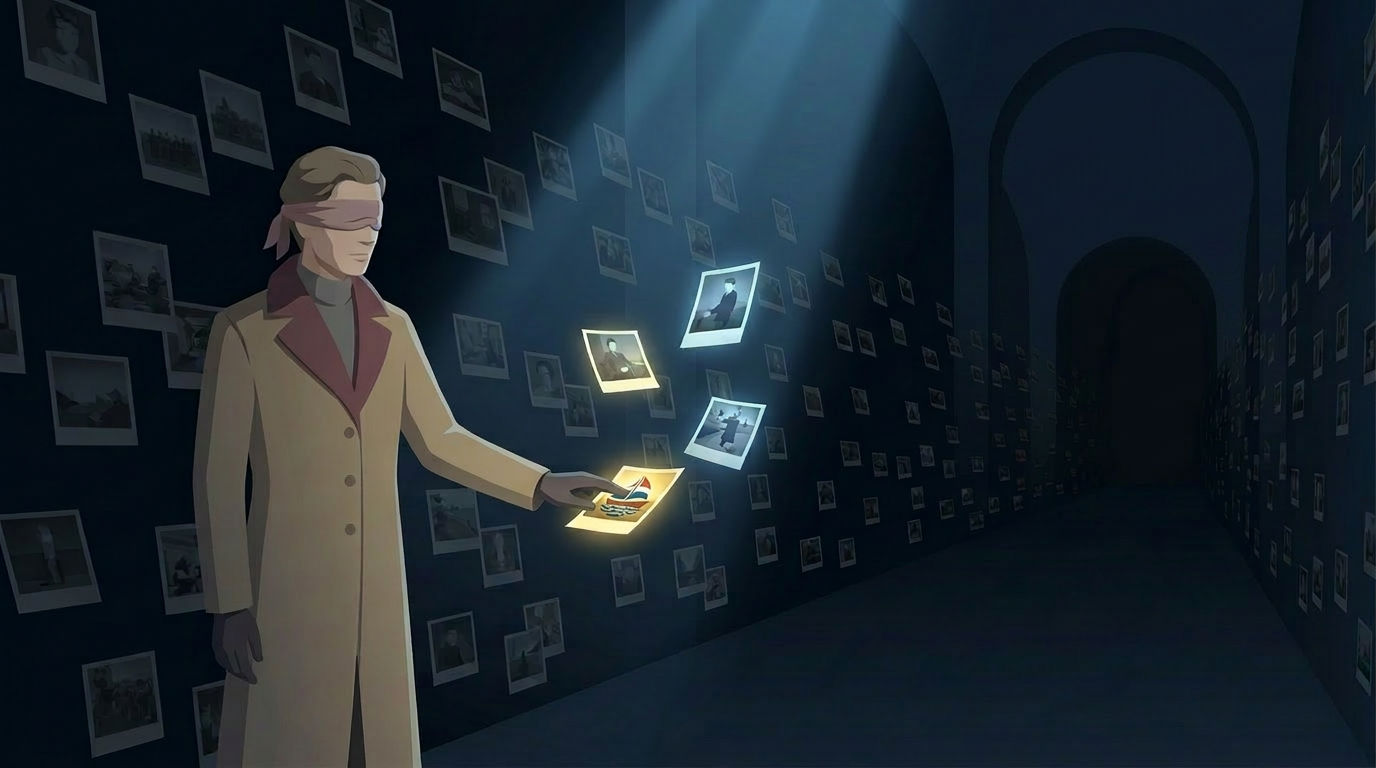

## **Task Description**

You are faced with 15,000 unknown images, and you can only see them through faint thumbnails and embedding vectors. The images belong to a fifty-class world (animals, plants, vehicles and everyday objects selected from CIFAR-100), but not a single image has a label.

Your budget is enough to label exactly **300 images**. Based on the 300 images you select, the evaluator builds a simple **prototype model**: for each class it averages the embedding vectors of the selected images, L2-normalizes the centroids, and then classifies every image in the test set by cosine similarity.

Your task: select 300 indices out of the 15,000 that yield the best prototype model.

**What you get:**

* `pool_emb.npy`: (15000, 384) DINOv2 embedding vectors
* `pool_thumbs.zip`: 15,000 thumbnails of 32×32 PNGs (for visual inspection)
* `seed_emb.npy`: (200, 384) labeled seed embedding vectors
* `seed_labels.npy`: (200,) seed labels, values between 0 and 49

**What you submit:** a single `submission.csv` file with an `id,target` header and exactly 300 rows. The `id` is a sequence number 0..299, and `target` is a unique image index between 0 and 14,999.

**Scoring:** four partial scores (al_s1, al_s2, al_s3, al_s4), with a maximum of **10 points** per subtask. The exact definition of the partial scores can be found in the task description document.

**Restriction:** only the provided DINOv2 embedding vectors and the thumbnails may be used to analyze the image set. Using external pretrained image models (e.g. CLIP, BLIP, or other image classifiers) on the pool images for the purpose of class or label estimation is **not allowed**.

## **Useful Links**

- [DINOv2 (ViT-S/14) model card](https://huggingface.co/facebook/dinov2-small)
- [NumPy documentation](https://numpy.org/doc/stable/)
- [pandas documentation](https://pandas.pydata.org/docs/)
- [Cosine similarity (scikit-learn)](https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity)
- [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html)

## **Required Imports**

In the first cell we fix the random seed. This guarantees that on a re-run your strategy produces the same submission CSV. The server evaluates deterministically, so you get the same score for the same CSV.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# DO NOT MODIFY — with this seed you get the same submission CSV
# on every re-run. The server is deterministic.
# ═══════════════════════════════════════════════════════════════════
import os
import random
import zipfile
import numpy as np
import pandas as pd

# --- Reproducibility: we tie every source of randomness to a single seed ---
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)   # set/dict iteration order, for child processes
random.seed(SEED)                          # stdlib random
np.random.seed(SEED)                       # numpy global RNG

# Optional: if you also use torch, we fix it there as well
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

## **Downloading the Dataset**

We download the four files from Google Drive. Replace the `<FILE_ID>` placeholder values with the identifiers provided by the competition organizers.

The cell runs safely both in Google Colab and locally. If `gdown` is not installed, it installs it automatically; if that fails (e.g. in an environment without internet), it prints the manual download URLs. If the files are already in the working directory, it skips the download.

In [ ]:
import os
import subprocess
import sys

FILES = {
    "pool_emb.npy":    "1wqtCW6KwjVCaqnT7Ycy6EmgP1EAXN25U",
    "pool_thumbs.zip": "1QDEhMHk-L1PtfliEGxdz3EPavDI-jXEm",
    "seed_emb.npy":    "1hn5WDIMQ-CfiiDoFDD0V8uEMbqS40FUz",
    "seed_labels.npy": "14mmvPJSt0POPx0GVpFxqpV_XMmR2AvoS",
}

missing = [name for name in FILES if not os.path.exists(name)]

if not missing:
    print("All files are present in the working directory — download skipped.")
else:
    try:
        import gdown  # type: ignore
    except ImportError:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown  # type: ignore
        except Exception:
            gdown = None  # type: ignore

    if gdown is None:
        print("gdown is not available. Download the following files manually into the working directory:\n")
        for name in missing:
            print(f"  https://drive.google.com/uc?id={FILES[name]}  ->  {name}")
    else:
        for name in missing:
            file_id = FILES[name]
            try:
                gdown.download(id=file_id, output=name, quiet=False)
            except Exception as e:
                print(f"  failed to download {name}: {e}")
                print(f"  manual download: https://drive.google.com/uc?id={file_id}")

## **Loading the Data**

In [ ]:
pool_emb    = np.load("pool_emb.npy")       # (15000, 384) float32
seed_emb    = np.load("seed_emb.npy")       # (200, 384)
seed_labels = np.load("seed_labels.npy")    # (200,) int — values 0..49

print("pool_emb:   ", pool_emb.shape,    pool_emb.dtype)
print("seed_emb:   ", seed_emb.shape,    seed_emb.dtype)
print("seed_labels:", seed_labels.shape, "\nnumber of classes:", np.unique(seed_labels).size)

# Extracting the thumbnails
with zipfile.ZipFile("pool_thumbs.zip") as z:
    z.extractall("pool_thumbs")

## **Example submission: the first 300 indices**

The cell below produces a valid `submission.csv`. The choice here is deliberately simple: the images with indices 0..299, as a starting example.

The format requirements:

* header `id,target`
* exactly 300 rows
* `id` is a sequence number 0..299
* `target` is a **unique** image index between 0 and 14999

In [ ]:
selected_indices = np.arange(300, dtype=np.int64)

# Validation: the evaluator checks these very same conditions.
assert len(selected_indices) == 300,                    "there must be 300 indices"
assert len(np.unique(selected_indices)) == 300,         "the indices must be unique"
assert selected_indices.min() >= 0,                     "indices cannot be negative"
assert selected_indices.max() <= 14_999,                "indices must be between 0 and 14999"

# Producing the submission CSV.
submission = pd.DataFrame({
    "id":     np.arange(300, dtype=np.int64),
    "target": selected_indices,
})
submission.to_csv("submission.csv", index=False)

print("Saved: submission.csv")
print(submission.head())

## **Your code starts here**

Replace the generation of `selected_indices` with your own strategy, then write out `submission.csv` again. The `pool_emb` matrix and `seed_emb` / `seed_labels` contain all the information you need for the selection.

In [ ]:
## TODO: your own selection logic goes here.

---

## 🎉 Good luck!

Upload the `submission.csv` file to the **DOCK** platform for all four subtasks (`al_s1`, `al_s2`, `al_s3`, `al_s4`). You may even upload a different CSV for each subtask if you want to optimize specifically for that particular criterion. You have at most **6 upload attempts** per subtask, and the score of your best submission counts.

---